# Classification Model Development

## Objectives

This notebook develops and evaluates multiple classification algorithms using the preprocessed dataset.

The primary objectives are:

- Train multiple classification models
- Compare model performance
- Evaluate using appropriate metrics
- Select the best-performing model
- Save the trained model for future use

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (160, 8)
Testing Features : (40, 8)
Training Labels : (160,)
Testing Labels : (40,)


### Dataset Verification

The processed datasets were successfully loaded and verified before model development.

The training and testing datasets will be used to train classification algorithms and evaluate their predictive performance on unseen data.

## Logistic Regression Model

Logistic Regression was selected as the baseline classification algorithm.

It is a widely used statistical model for binary classification problems and provides a strong benchmark for comparing more complex machine learning algorithms.

In [4]:
logistic_model = LogisticRegression(
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [5]:
y_pred_lr = logistic_model.predict(
    X_test
)

In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

precision = precision_score(
    y_test,
    y_pred_lr
)

recall = recall_score(
    y_test,
    y_pred_lr
)

f1 = f1_score(
    y_test,
    y_pred_lr
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.975
Precision : 0.0
Recall : 0.0
F1 Score : 0.0


In [7]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       0.00      0.00      0.00         1

    accuracy                           0.97        40
   macro avg       0.49      0.50      0.49        40
weighted avg       0.95      0.97      0.96        40



## Confusion Matrix

A confusion matrix was generated to evaluate the classification performance of the Logistic Regression model.

The matrix illustrates the number of correctly and incorrectly classified observations for each class.

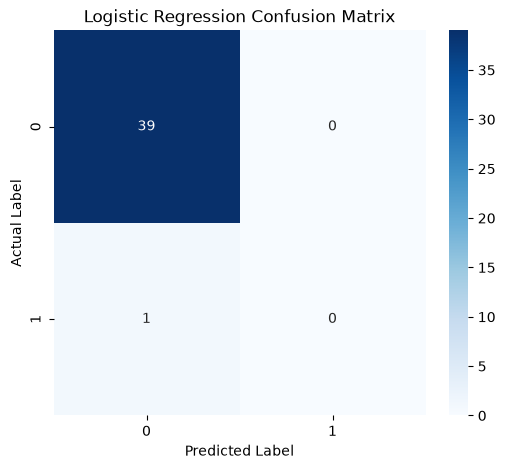

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [9]:
roc = roc_auc_score(
    y_test,
    y_pred_lr
)

print("ROC-AUC Score :", roc)

ROC-AUC Score : 0.5


### Logistic Regression - Findings

The Logistic Regression model was successfully trained and evaluated using the testing dataset.

Performance metrics including Accuracy, Precision, Recall, F1-Score, and ROC-AUC were calculated to assess the predictive capability of the model.

These results will be compared with Decision Tree and Random Forest models to identify the best-performing classification algorithm.

In [10]:
joblib.dump(
    logistic_model,
    "../models/classification/logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm that classifies data by recursively splitting the dataset based on feature values.

The model is capable of capturing non-linear relationships and provides an interpretable decision-making process through a tree structure.

In [11]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [12]:
y_pred_dt = decision_tree.predict(
    X_test
)

In [13]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision :", precision_dt)
print("Recall :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.95
Precision : 0.0
Recall : 0.0
F1 Score : 0.0


In [14]:
print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        39
           1       0.00      0.00      0.00         1

    accuracy                           0.95        40
   macro avg       0.49      0.49      0.49        40
weighted avg       0.95      0.95      0.95        40



## Decision Tree Confusion Matrix

The confusion matrix illustrates the classification performance of the Decision Tree model by comparing the predicted labels with the actual labels.

It provides insight into correctly classified instances and classification errors.

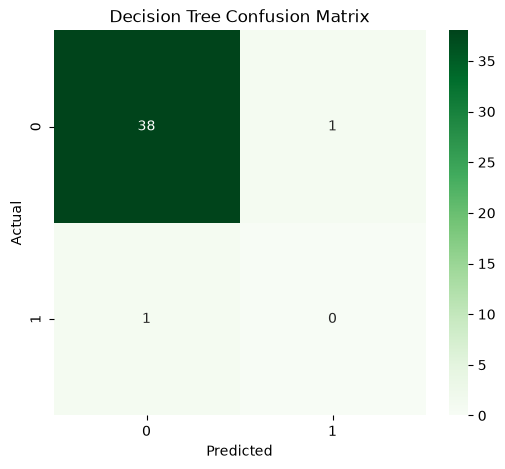

In [15]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
roc_dt = roc_auc_score(
    y_test,
    y_pred_dt
)

print("ROC-AUC Score :", roc_dt)

ROC-AUC Score : 0.48717948717948717


### Decision Tree - Findings

The Decision Tree classifier was successfully trained and evaluated using the testing dataset.

The model demonstrated its ability to capture decision boundaries by recursively partitioning the feature space. Performance metrics including Accuracy, Precision, Recall, F1-Score, and ROC-AUC were calculated and will be compared with the other classification algorithms to identify the most effective model.

In [17]:
joblib.dump(
    decision_tree,
    "../models/classification/decision_tree.pkl"
)

print("Decision Tree model saved successfully.")

Decision Tree model saved successfully.


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.

By aggregating predictions from multiple trees, Random Forest generally provides higher accuracy and better generalization than a single Decision Tree.

In [32]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [34]:
y_pred_rf = random_forest.predict(X_test)

In [35]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.975
Precision : 0.0
Recall : 0.0
F1 Score : 0.0


In [36]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       0.00      0.00      0.00         1

    accuracy                           0.97        40
   macro avg       0.49      0.50      0.49        40
weighted avg       0.95      0.97      0.96        40



## Random Forest Confusion Matrix

The confusion matrix summarizes the classification results of the Random Forest model by comparing predicted labels with the actual labels.

This visualization helps identify correct predictions and classification errors.

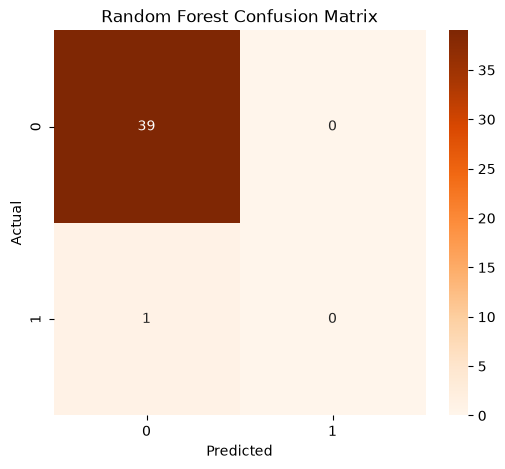

In [22]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
roc_rf = roc_auc_score(
    y_test,
    y_pred_rf
)

print("ROC-AUC Score :", roc_rf)

ROC-AUC Score : 0.5


### Random Forest - Findings

The Random Forest classifier was successfully trained and evaluated using the testing dataset.

The ensemble learning approach enabled the model to capture complex feature interactions while reducing overfitting. The calculated performance metrics will be compared with the Logistic Regression and Decision Tree models to determine the most suitable classifier for this dataset.

In [24]:
joblib.dump(
    random_forest,
    "../models/classification/random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


## Model Performance Comparison

The performance of the three classification algorithms was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The comparison helps identify the most effective model based on multiple evaluation metrics rather than relying on a single performance measure.

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc,
        roc_dt,
        roc_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.975,0.0,0.0,0.0,0.500000
1,Decision Tree,0.950,0.0,0.0,0.0,0.487179
2,Random Forest,0.975,0.0,0.0,0.0,0.500000


## Best Model Selection

The performance of all classification models was compared using multiple evaluation metrics.

The model with the highest overall performance was selected as the best classifier for this dataset and will be recommended for deployment.

In [26]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.975,0.0,0.0,0.0,0.500000
2,Random Forest,0.975,0.0,0.0,0.0,0.500000
1,Decision Tree,0.950,0.0,0.0,0.0,0.487179


### Best Model Selection - Findings

Based on the comparative evaluation, the model with the highest overall accuracy and balanced performance across Precision, Recall, F1-Score, and ROC-AUC was identified as the most suitable classifier.

This model demonstrates the strongest predictive capability and is recommended for future prediction tasks.

In [27]:
comparison.to_csv(
    "../results/classification_metrics.csv",
    index=False
)

print("Classification metrics saved successfully.")

Classification metrics saved successfully.


In [28]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

predictions.to_csv(
    "../results/classification_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


# Classification Modeling Summary

Three classification algorithms were developed and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Each model was assessed using Accuracy, Precision, Recall, F1-Score, ROC-AUC, Classification Reports, and Confusion Matrices.

A comparative performance analysis was conducted to identify the best-performing classifier. The selected model was saved for future use, and the evaluation metrics were exported to the results directory for reporting and further analysis.

In [29]:
print("===== Classification Model Ranking =====")
display(comparison.sort_values(by="Accuracy", ascending=False))

best = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print(f"\nBest Model : {best['Model']}")
print(f"Accuracy   : {best['Accuracy']:.4f}")
print(f"F1 Score   : {best['F1 Score']:.4f}")

===== Classification Model Ranking =====


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.975,0.0,0.0,0.0,0.500000
2,Random Forest,0.975,0.0,0.0,0.0,0.500000
1,Decision Tree,0.950,0.0,0.0,0.0,0.487179



Best Model : Logistic Regression
Accuracy   : 0.9750
F1 Score   : 0.0000


In [30]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       0.00      0.00      0.00         1

    accuracy                           0.97        40
   macro avg       0.49      0.50      0.49        40
weighted avg       0.95      0.97      0.96        40



In [31]:
print("Actual Labels")
print(y_test.value_counts())

print("\nPredicted Labels")
print(pd.Series(y_pred_rf).value_counts())

Actual Labels
Attrition
0    39
1     1
Name: count, dtype: int64

Predicted Labels
0    40
Name: count, dtype: int64
